### Importing Libraries

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## connecting to the SQL database

In [223]:
import sqlite3
connection = sqlite3.connect(r"C:\Users\HP\OneDrive\Desktop\Nordex_Shift_System\ShiftData.db")
Shift_Data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


### Basic Dataset Overview
* shift_Data.column - List the column names in the dataset
* shift_Data.shape - getting the shape of the dataset
* Format the data to proper date format
* df.duplicated().sum() - checking for duplicates in our dataset
* df.isna().sum() - checking for missing values in the dataset
* df.describe() - checking the statistical Distribution of our dataset

In [224]:
Shift_Data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [225]:
Shift_Data.shape

(296334, 31)

In [226]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [227]:
# properly formatting our columns that has the datatype of data into proper datetime format
Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'], format='mixed')
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'], format='mixed')

In [228]:

Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [229]:
# this cells checks if the dataset has duplicates
Shift_Data.duplicated().sum()

np.int64(0)

In [230]:
# Check for missing values
Shift_Data.isnull().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [231]:
## this checks the statistical distribution of our dataset
Shift_Data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000
mean,2.048142,2026-06-03 14:23:06.478770688,2026-06-03 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118
min,1.000000,2026-06-03 06:00:00,2026-06-03 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000
25%,1.000000,2026-06-03 06:00:00,2026-06-03 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000
50%,2.000000,2026-06-03 14:00:00,2026-06-03 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000
75%,3.000000,2026-06-03 22:00:00,2026-06-03 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000
max,3.000000,2026-06-03 22:00:00,2026-06-03 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084


## Filling the missing values
* df.isna().sum() - identify the columns that has missing values and show how many values are missing
* df.sort_values(by="date") - sort the dataset chronologically, which is essential for timeseries before using the forward of filling missing values
* filling the missing values with the last known values, and any other gap remains with mean

In [232]:
Shift_Data = Shift_Data.sort_values(by='date')

# fill temperature & Humidity columns
Shift_Data['temperature'] = Shift_Data['temperature'].ffill().fillna(Shift_Data['temperature'].mean())
Shift_Data['humidity'] = Shift_Data['humidity'].ffill().fillna(Shift_Data['humidity'].mean())

# Fill Timestamp
Shift_Data['timestamp'] = Shift_Data['timestamp'].ffill()

In [233]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [234]:
# fill the categorical fields
Shift_Data["issue_type"] = Shift_Data["issue_type"].fillna("No Issue")
Shift_Data["resolved_by"] = Shift_Data["resolved_by"].fillna("No Maintenance")

# fill the downtime column
Shift_Data["maintenance_downtime"] = Shift_Data["maintenance_downtime"].fillna(0)
Shift_Data = Shift_Data.drop(columns=['maintenance_id'])

In [235]:
Shift_Data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

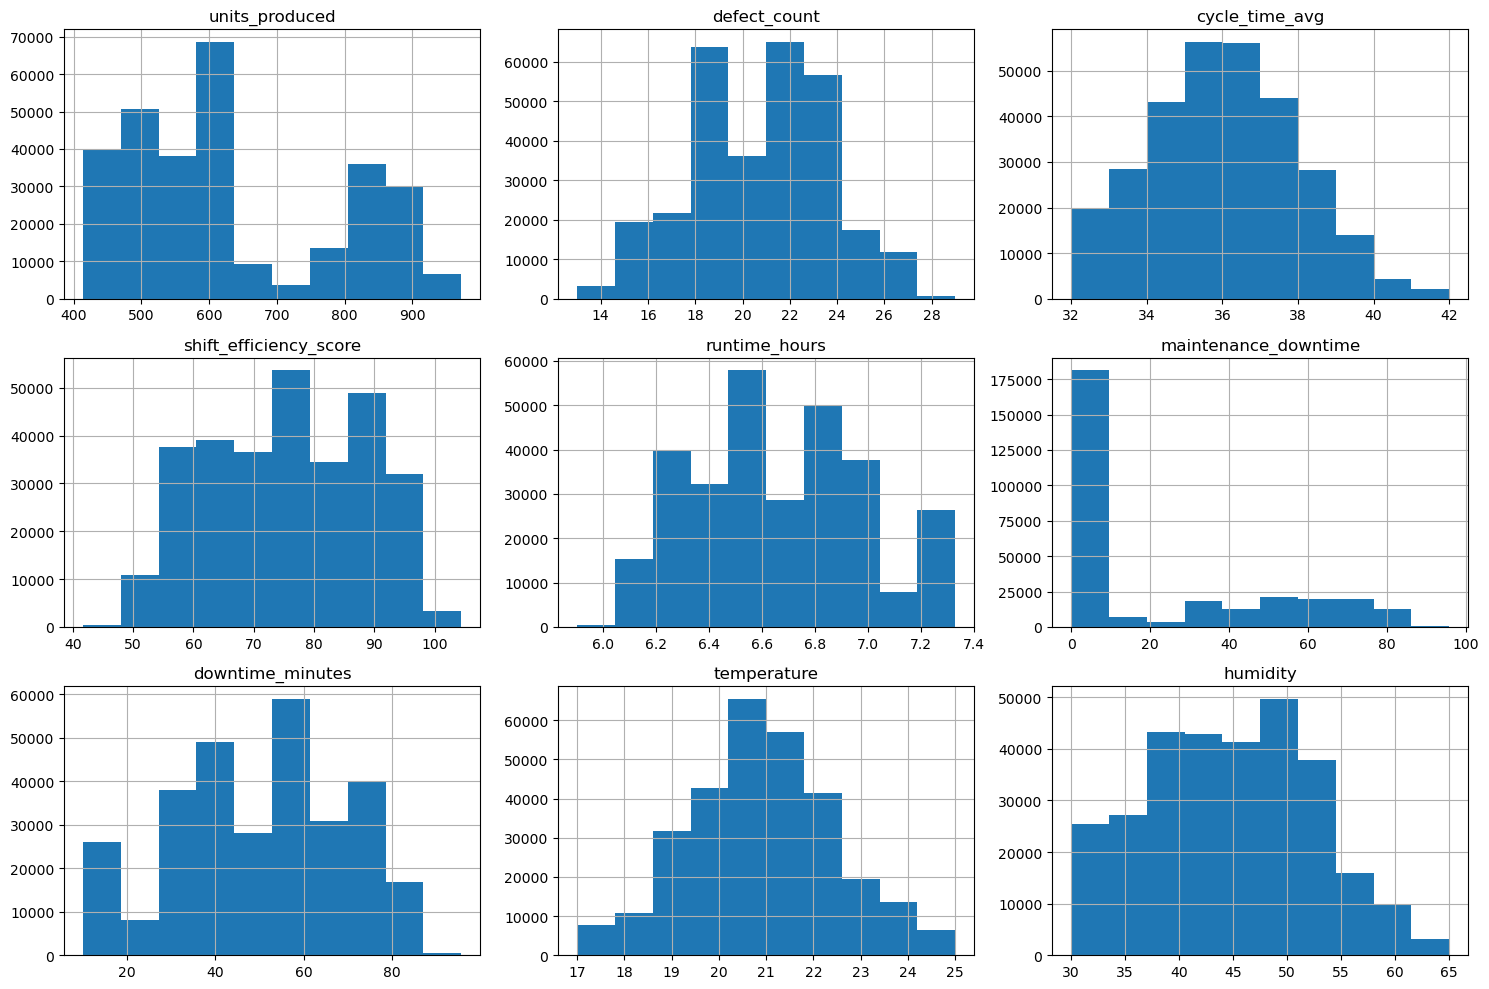

In [236]:
# Numerical Data Analysis
num_cols = ["units_produced", "defect_count", "cycle_time_avg", 
            "shift_efficiency_score", "runtime_hours", "maintenance_downtime", "downtime_minutes",
            "temperature", "humidity"]

Shift_Data[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

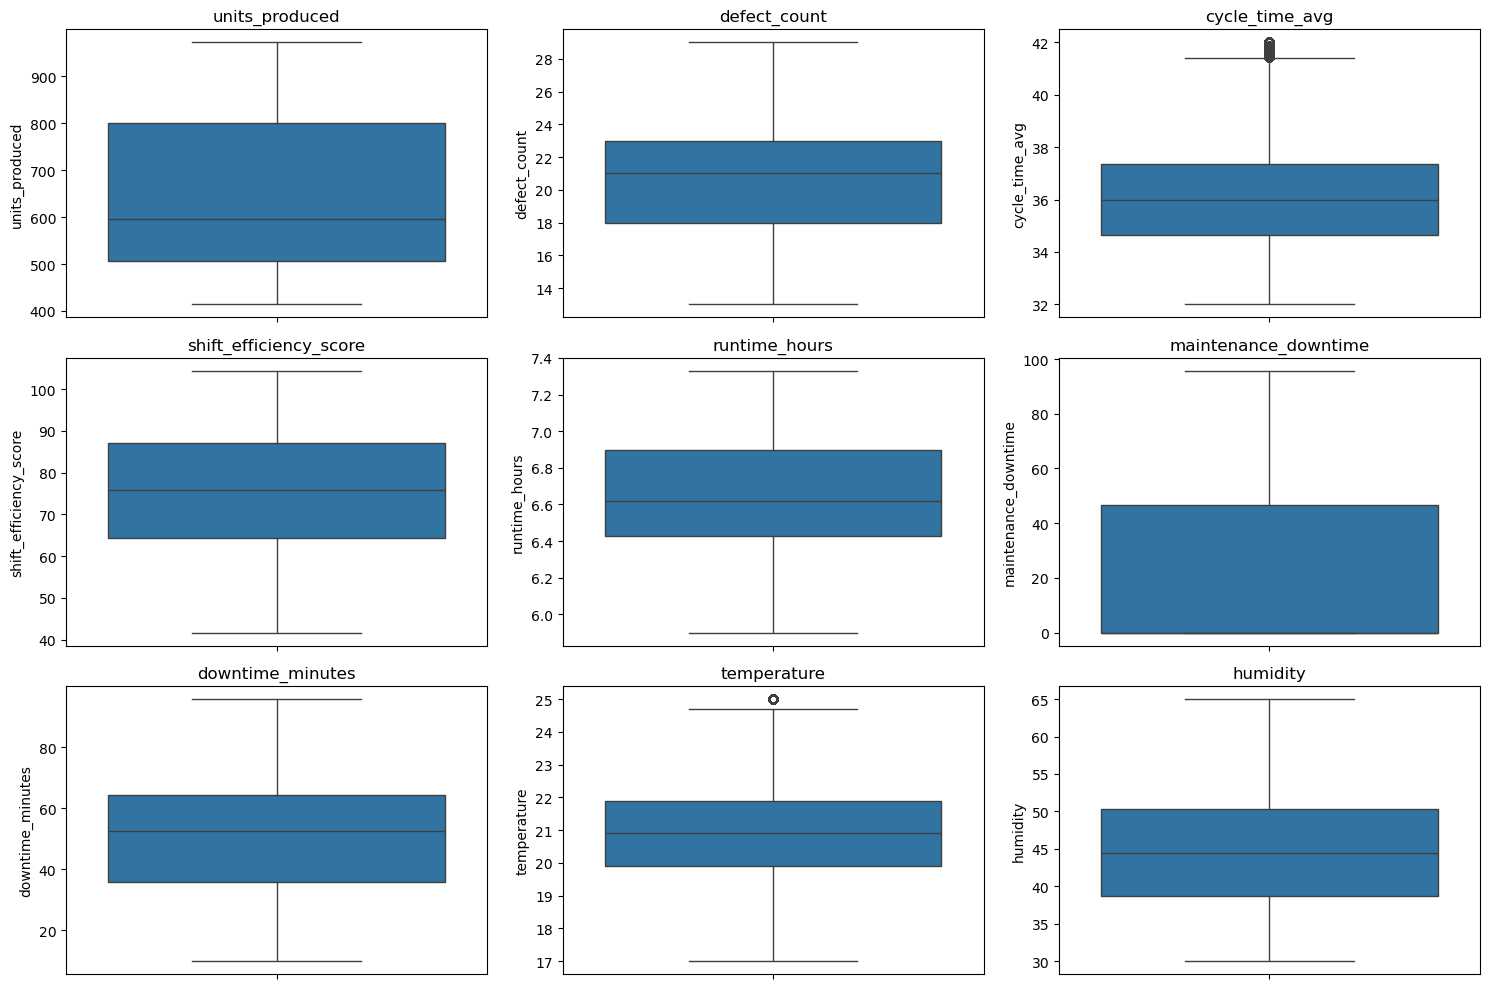

In [237]:
## Using the box to check if our data has any outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=Shift_Data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Categorical Variable Analysis

In [238]:
categorical_cols = ["shift_name", "machine_status", "issue_type", 
                    "resolved_by", "defect_type", "inspection_result", "severity", "experience_level"]
for column in categorical_cols:
    print(f"Value counts for {column}:\n")
    print(Shift_Data[column].value_counts())

Value counts for shift_name:

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for machine_status:

machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
Value counts for issue_type:

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for resolved_by:

resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07            12427
TECH_08            12290
TECH_02            12065
TECH_10            11977
TECH_05            11743
TECH_04            11275
TECH_01            10522
TECH_09            10441
TECH_06             9954
Name: count, dtype: int64
Value counts for defect_type:

defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
Value counts for inspection_result:

inspec

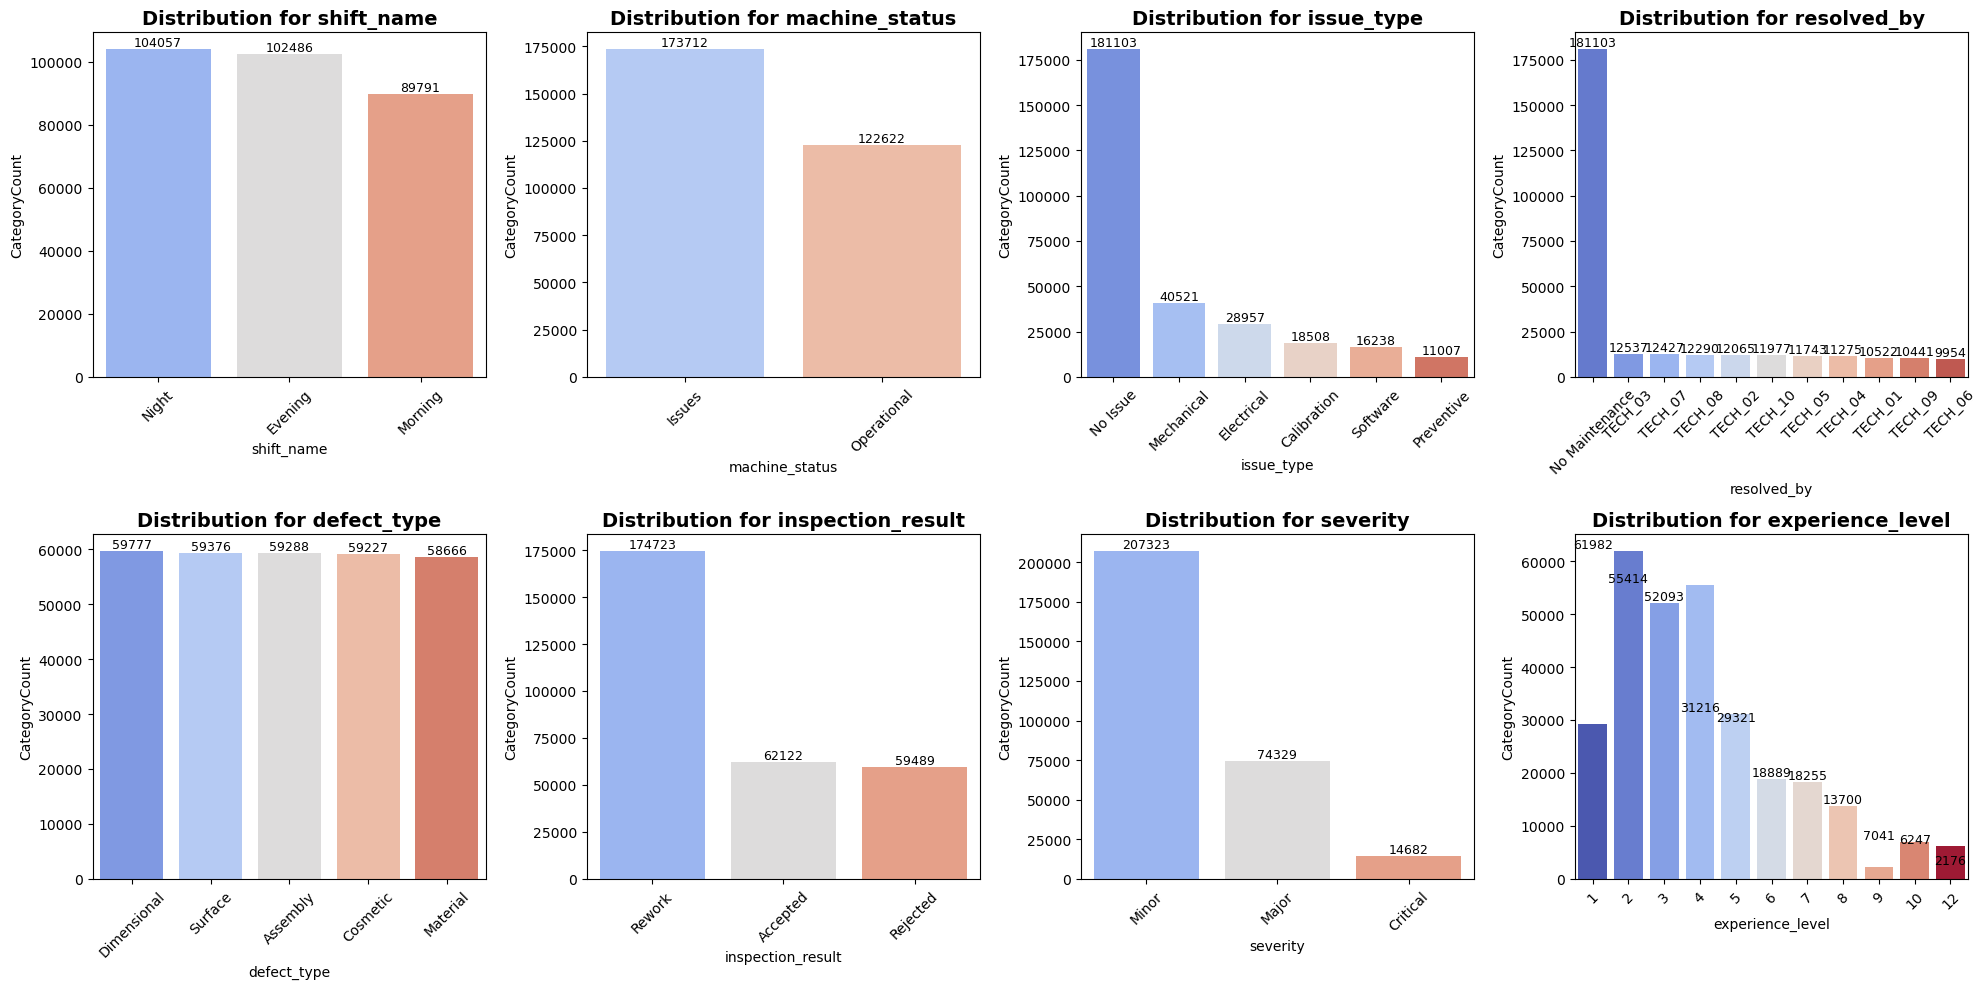

In [239]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for index, column in enumerate(categorical_cols):
    counts = Shift_Data[column].value_counts().reset_index()
    counts.columns = [column, 'count']
    sns.barplot(data=counts, x=column, y='count', hue=column, palette='coolwarm',
                legend=False, ax=axes[index])

    axes[index].tick_params(axis='x', rotation=45)
    axes[index].set_title(f"Distribution for {column}", fontsize=14, fontweight='bold')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("CategoryCount")

    for j, v in enumerate(counts['count']):
        axes[index].text(j, v, f"{v:}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Operational Performance during Maintainance vs No maintainance

In [240]:
Shift_Data["maintenance_flag"].value_counts()

maintenance_flag
0    242487
1     53847
Name: count, dtype: int64

In [241]:
# Maintainance Flag Analysis
maintenance_data = Shift_Data.groupby('maintenance_flag')[num_cols].mean()

In [242]:
maintenance_data.head()

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,maintenance_downtime,downtime_minutes,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,13.520254,49.281488,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.701075,53.954773,20.860356,44.613007


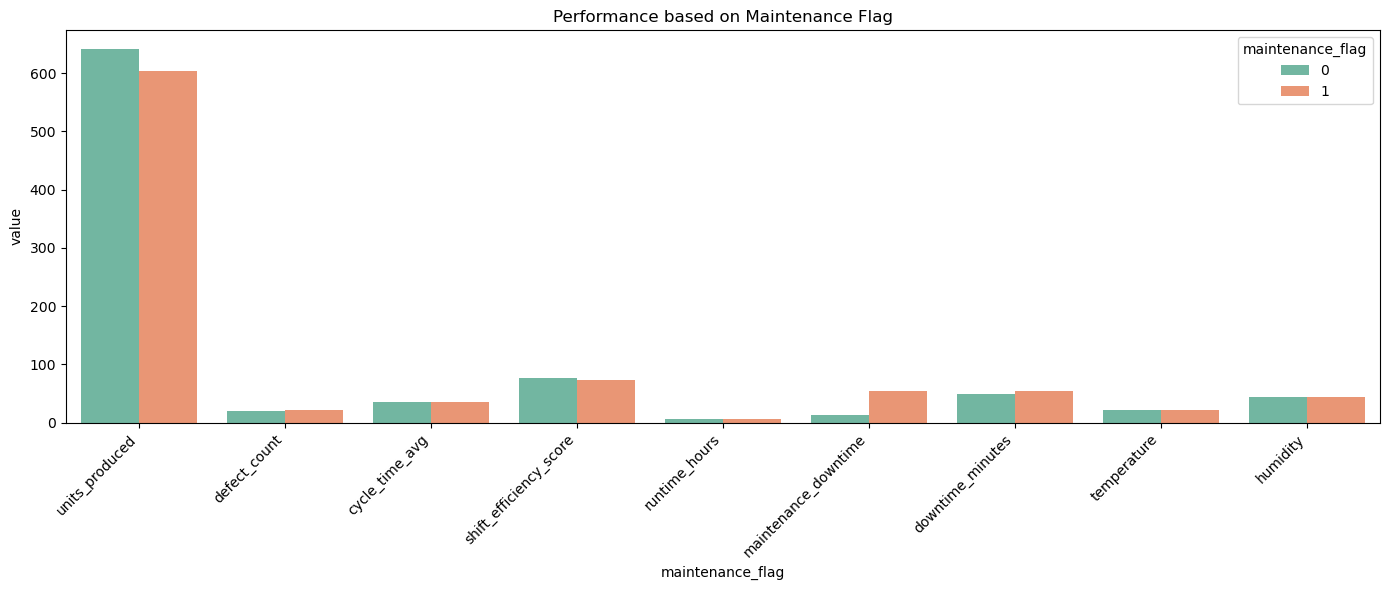

In [243]:
maintainance_data = maintenance_data.reset_index()
maintainance_plot_melt = maintainance_data.melt(
    id_vars=['maintenance_flag'], var_name='performance',
    value_name='value'
    )

plt.figure(figsize=(14, 6))
sns.barplot(
    data=maintainance_plot_melt, x='performance', y='value',
    hue='maintenance_flag', palette='Set2'
    )
plt.xticks(rotation=45, ha='right')
plt.title("Performance based on Maintenance Flag")
plt.xlabel("maintenance_flag")
plt.tight_layout()
plt.show()

### Shift Performance Analysis

In [244]:
shift_performance_data = Shift_Data.groupby('shift_name').agg({
    'units_produced': ['mean', 'sum'],
    'cycle_time_avg': 'mean',
    'defect_count': 'mean',
    'downtime_minutes': ['mean', 'sum'],
    'shift_efficiency_score': 'mean'
}).reset_index()

shift_performance_data.columns = [
    'shift_name', 'average_units_produced', 'total_units_produced',
    'average_cycle_time', 'average_defect_count', 'average_downtime', 'total_downtime',
    'average_efficiency'
]
# calculate defect rate
defect_sum = Shift_Data.groupby('shift_name')['defect_count'].sum().values
units_sum = Shift_Data.groupby('shift_name')['units_produced'].sum().values

shift_performance_data['defect_rate'] = (defect_sum / units_sum) * 100
shift_performance_data.sort_values(by='average_units_produced', ascending=False)

,shift_name,average_units_produced,total_units_produced,average_cycle_time,average_defect_count,average_downtime,total_downtime,average_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


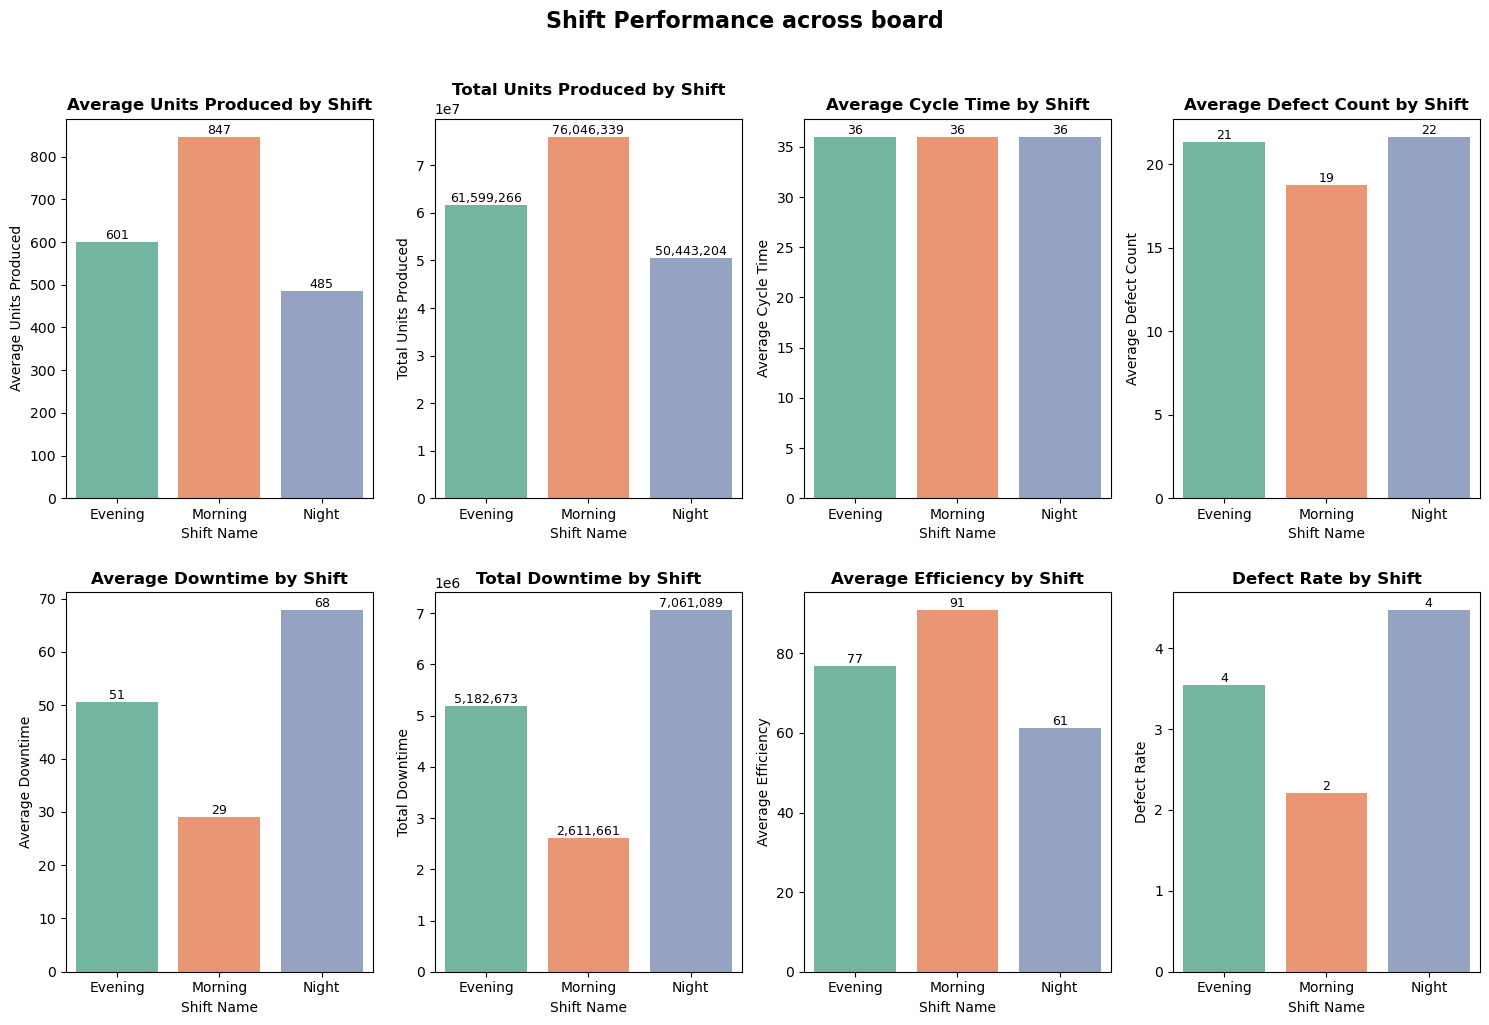

In [245]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()
metrics = ['average_units_produced', 'total_units_produced', 'average_cycle_time', 
           'average_defect_count', 'average_downtime', 'total_downtime', 
           'average_efficiency', 'defect_rate']
for i, metric in enumerate(metrics):
    sns.barplot(data=shift_performance_data, x='shift_name', 
                y=metric, hue='shift_name', palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f"{metric.replace('_', ' ').title()} by Shift", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Shift Name")
    axes[i].set_ylabel(metric.replace('_', ' ').title())
    
    for j, v in enumerate(shift_performance_data[metric]):
        if 'units' in metric:
            axes[i].text(j, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)
        else:
            axes[i].text(j, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)
plt.suptitle("Shift Performance across board", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
                    

### Shift Performance Based On Production Output Per Hour

In [246]:
Shift_Data['total_operating_hours'] = Shift_Data['runtime_hours'] + (Shift_Data['downtime_minutes'] / 60)

output_per_hour = Shift_Data.groupby('shift_name').apply(
    lambda x: x['units_produced'].sum() / x['total_operating_hours'].sum(),
    include_groups=False
)
output_per_hour

shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
dtype: float64

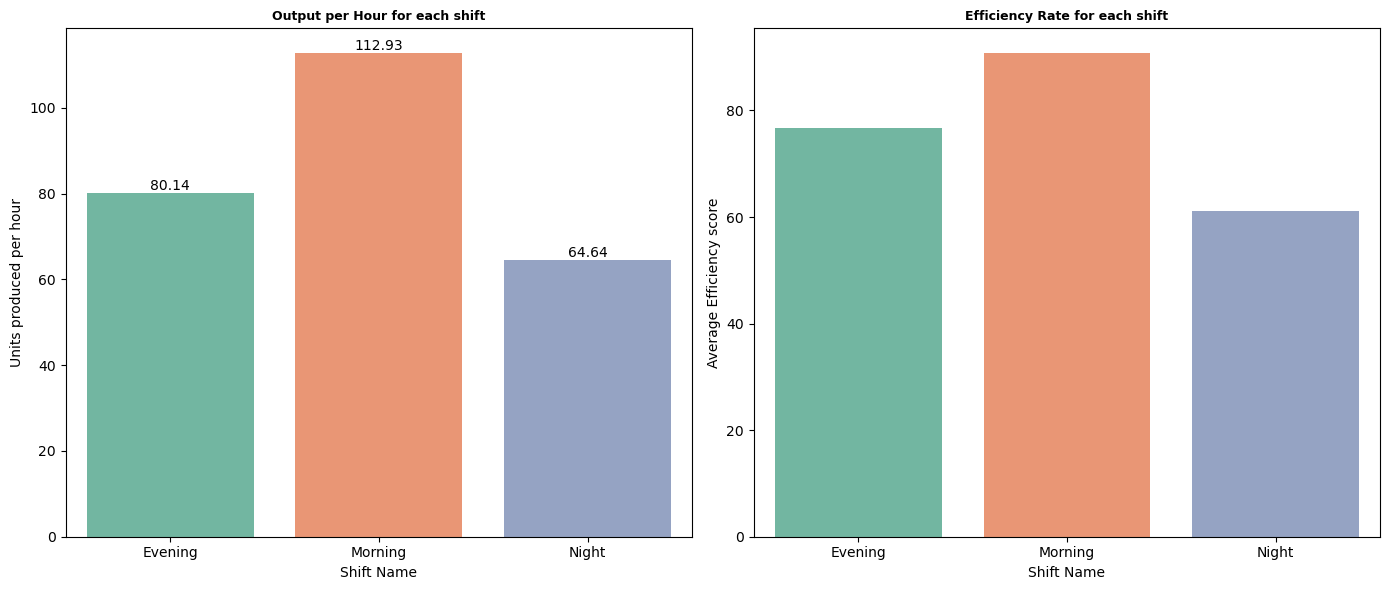

In [247]:
output_per_hour_data = output_per_hour.reset_index()
output_per_hour_data.columns = ['shift_name', 'units_per_hour']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Output per hour by shift
sns.barplot(data=output_per_hour_data, x='shift_name', y='units_per_hour',
            hue='shift_name', palette='Set2', ax=axes[0], legend=False)
axes[0].set_title("Output per Hour for each shift", fontsize=9, fontweight='bold')
axes[0].set_xlabel("Shift Name")
axes[0].set_ylabel("Units produced per hour")
for i, v in enumerate(output_per_hour_data['units_per_hour']):
    axes[0].text(i, v, f"{v:.2f}", ha='center', va='bottom')

merged_data = shift_performance_data.merge(output_per_hour_data, on='shift_name')

# Plot 2: Shift efficiency score
sns.barplot(data=merged_data, x='shift_name', y='average_efficiency',
            hue='shift_name', palette='Set2', ax=axes[1], legend=False)
axes[1].set_title("Efficiency Rate for each shift", fontsize=9, fontweight='bold')
axes[1].set_xlabel("Shift Name")
axes[1].set_ylabel("Average Efficiency score")

plt.tight_layout()
plt.show()

In [248]:
production = (
    Shift_Data[['production_id', 'shift_id',
                'date', 'units_produced', 'defect_count']]
    .drop_duplicates(subset=['production_id'])
)
machine = (
    Shift_Data[['machine_id', 'date', 'shift_id', 'downtime_minutes']]
    .drop_duplicates()
    .copy()
)

In [249]:
production.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [250]:
production.shape

(13650, 5)

In [251]:
machine.head()

,machine_id,date,shift_id,downtime_minutes
0,MC_001,2024-01-01,1,15.39
2308,MC_002,2024-01-01,3,53.73
2309,MC_003,2024-01-01,3,51.90
2331,MC_004,2024-01-01,3,54.45
2281,MC_001,2024-01-01,3,52.99


In [252]:
machine.shape

(13650, 4)

### OEE Metrics Calculation

In [253]:
PLANNED = 7.5
THEO = 100.0

machine['available_machine'] = (1 - (machine['downtime_minutes'] / (PLANNED * 60))).clip(0, 1)

available_machine_agg = (
    machine.groupby(['date', 'shift_id'])['available_machine']
    .mean().reset_index()
    .rename(columns={'available_machine': 'average_machine_availability'})
)

In [254]:
available_machine_agg.head()

,date,shift_id,average_machine_availability
0,2024-01-01,1,0.963687
1,2024-01-01,2,0.920976
2,2024-01-01,3,0.881807
3,2024-01-02,1,0.965439
4,2024-01-02,2,0.919042


In [255]:
available_machine_agg.shape

(273, 3)

In [256]:
# merging availability into production
merged_production_data = production.merge(available_machine_agg, on=['date', 'shift_id'], how='left')
merged_production_data['average_machine_availability'] = merged_production_data['average_machine_availability'].fillna(1)

# performance based on the planned time (not run time)
merged_production_data['performance'] = (merged_production_data['units_produced'] / (PLANNED * THEO)).clip(0, 1)

# Quality
merged_production_data['quality'] = 1 - (merged_production_data['defect_count'] / merged_production_data['units_produced'])
merged_production_data['quality'] = merged_production_data['quality'].fillna(1).clip(0, 1)

# final OEE calculation
merged_production_data['oee_est'] = (
    merged_production_data['average_machine_availability'] *
    merged_production_data['performance'] *
    merged_production_data['quality']
)
merged_production_data['month'] = merged_production_data['date'].dt.month

In [257]:
merged_production_data.head()

,production_id,shift_id,date,units_produced,defect_count,average_machine_availability,performance,quality,oee_est,month
0,1,1,2024-01-01,929,20,0.963687,1.000000,0.978471,0.942940,1
1,102,3,2024-01-01,530,21,0.881807,0.706667,0.960377,0.598453,1
2,103,3,2024-01-01,489,22,0.881807,0.652000,0.955010,0.549072,1
3,104,3,2024-01-01,527,21,0.881807,0.702667,0.960152,0.594926,1
4,101,3,2024-01-01,555,21,0.881807,0.740000,0.962162,0.627846,1


In [258]:
## monthly OEE (overall equipment effectiveness for each month)
monthly_oee = (
    merged_production_data.groupby('month')['oee_est'].mean().sort_index()
)
# print to confirm it matches the earlier value
for month, value in monthly_oee.items():
    print(f"Month: {month} OEE: {value*100:.2f}%")

Month: 1 OEE: 74.90%
Month: 2 OEE: 68.53%
Month: 3 OEE: 68.83%


In [259]:
if 1 in monthly_oee.index and 3 in monthly_oee.index:
    m1 = monthly_oee.loc[1]
    m3 = monthly_oee.loc[3]
    degredation = ((m1 - m3) / m1) * 100
    print(f'Quarterly degredation(month 1 -> month 3): {degredation:.2f}%')
else:
    print('could not find month 1 and 3 in the data to compute degredation process or curve')

Quarterly degredation(month 1 -> month 3): 8.10%


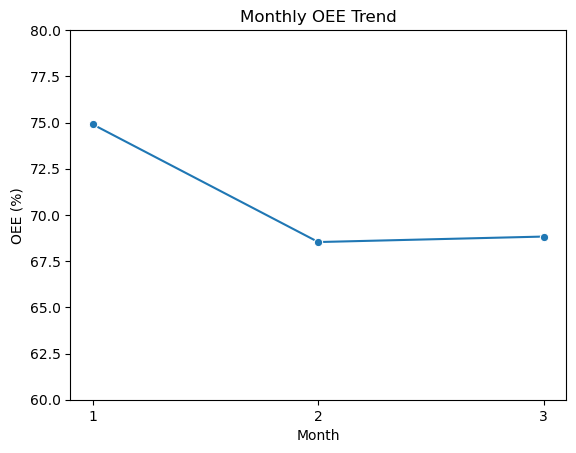

In [260]:
monthly_oee_df = monthly_oee.reset_index()
monthly_oee_df['OEE_percentage'] = monthly_oee_df['oee_est'] * 100

sns.lineplot(data=monthly_oee_df, x='month', y='OEE_percentage', marker='o')
plt.title("Monthly OEE Trend")
plt.ylabel("OEE (%)")
plt.ylim(60, 80)
plt.xticks([1, 2, 3])
plt.xlabel("Month")
plt.show()

### Experience vs the defect counts that occured during production

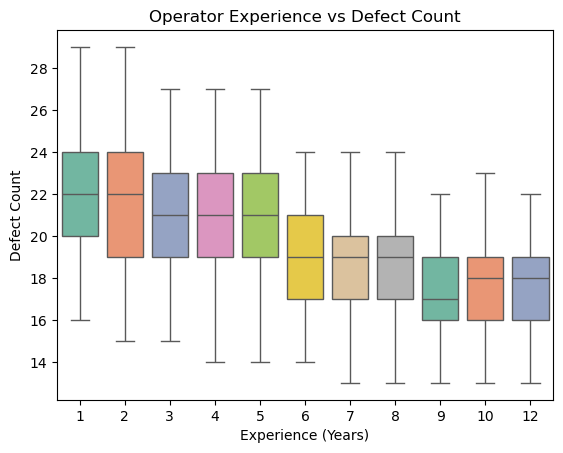

In [261]:
sns.boxplot(data=Shift_Data, x='experience_level', y='defect_count',
            hue='experience_level', palette='Set2', legend=False)
plt.title("Operator Experience vs Defect Count")
plt.xlabel("Experience (Years)")
plt.ylabel("Defect Count")
plt.show()

### feature Engineering

In [262]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [263]:
Shift_Data.shape

(296334, 31)

In [264]:
# Engineering new features
import pandas as pd
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])

# fixing the overnight shift and 1 day where the end time < start time
mask = Shift_Data['end_time'] < Shift_Data['start_time']
Shift_Data.loc[mask, 'end_time'] = Shift_Data.loc[mask, 'end_time'] + pd.Timedelta(days=1)

# Shift Duration
Shift_Data['shift_duration'] = (Shift_Data['end_time'] - Shift_Data['start_time']).dt.total_seconds() / 3600

# Defect rate
Shift_Data['defect_rate'] = Shift_Data['defect_count'] / Shift_Data['units_produced'].replace(0, pd.NA)
Shift_Data['downtime_ratio'] = Shift_Data['downtime_minutes'] / (Shift_Data['shift_duration'] * 60)

# temporal features
Shift_Data['day_of_week'] = Shift_Data['date'].dt.dayofweek
Shift_Data['hour_of_day'] = Shift_Data['date'].dt.hour

In [265]:
# drop identifiers and leakage and raw datetime columns
columns_to_drop = [
    # identifiers
    'shift_id', 'operator_id', 'operator_name', 'machine_id', 'production_id', 
#leakage
'qc_id', 'resolved_by', 'timestamp',
#Raw datetime columns
'start_time', 'end_time', 'date']
Shift_Data.drop(columns=columns_to_drop, inplace=True)



In [266]:
Shift_Data.columns

Index(['shift_name', 'supervisor_id', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'experience_level',
       'skill_category', 'runtime_hours', 'downtime_minutes',
       'maintenance_flag', 'machine_status', 'issue_type',
       'maintenance_downtime', 'defect_type', 'severity', 'inspection_result',
       'temperature', 'humidity', 'total_operating_hours', 'shift_duration',
       'defect_rate', 'downtime_ratio', 'day_of_week', 'hour_of_day'],
      dtype='object')

In [267]:
Shift_Data.duplicated().sum()

np.int64(119015)

In [268]:
Shift_Data.drop_duplicates(inplace=True)

In [269]:
Shift_Data.duplicated().sum()

np.int64(0)

### Modelling Phase

In [270]:
Shift_Data.isna().sum()

shift_name                0
supervisor_id             0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
experience_level          0
skill_category            0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
total_operating_hours     0
shift_duration            0
defect_rate               0
downtime_ratio            0
day_of_week               0
hour_of_day               0
dtype: int64

In [271]:
Shift_Data.head()

,shift_name,supervisor_id,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,skill_category,runtime_hours,downtime_minutes,...,severity,inspection_result,temperature,humidity,total_operating_hours,shift_duration,defect_rate,downtime_ratio,day_of_week,hour_of_day
0,Morning,SUP_01,929,20,35.65,95.945255,7,Expert,7.24,15.39,...,Minor,Rework,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,0
2308,Night,SUP_03,530,21,35.61,66.604731,5,Intermediate,6.60,53.73,...,Minor,Accepted,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,0
2309,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Major,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,0
2310,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,0
2311,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,0


In [272]:
Shift_Data['shift_efficiency_score'].describe()

count    177319.000000
mean         75.829886
std          12.955768
min          41.690033
25%          64.595342
50%          76.253965
75%          87.578778
max         104.379285
Name: shift_efficiency_score, dtype: float64

In [273]:
Shift_Data.drop(columns=['supervisor_id', 'inspection_result'], inplace=True)

### Data Splitting

In [274]:
x = Shift_Data.drop(columns=['shift_efficiency_score'])
y = Shift_Data['shift_efficiency_score']

In [275]:
x.head()

,shift_name,units_produced,defect_count,cycle_time_avg,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,machine_status,...,defect_type,severity,temperature,humidity,total_operating_hours,shift_duration,defect_rate,downtime_ratio,day_of_week,hour_of_day
0,Morning,929,20,35.65,7,Expert,7.24,15.39,0,Operational,...,Material,Minor,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,0
2308,Night,530,21,35.61,5,Intermediate,6.60,53.73,0,Issues,...,Surface,Minor,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,0
2309,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,...,Cosmetic,Major,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,0
2310,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,...,Dimensional,Minor,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,0
2311,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,...,Assembly,Minor,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,0


In [276]:
y.head()

0       95.945255
2308    66.604731
2309    61.238523
2310    61.238523
2311    61.238523
Name: shift_efficiency_score, dtype: float64

In [277]:
# splitting the data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [278]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(141855, 22)
(35464, 22)
(141855,)
(35464,)


In [279]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Numerical_features = [
    'units_produced',
    'defect_count',
    'cycle_time_avg',
    'experience_level',
    'runtime_hours',
    'downtime_minutes',
    'maintenance_flag',
    'maintenance_downtime',
    'temperature',
    'humidity',
    'total_operating_hours',
    'shift_duration',
    'defect_rate',
    'downtime_ratio',
    'day_of_week',
    'hour_of_day'
]

Categorical_features = [
    'shift_name', 'machine_status', 'issue_type', 
    'defect_type', 'severity', 'skill_category'
]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', Numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), Categorical_features)
    ]
)

In [280]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner="onyedikakenechukwu7",
             repo_name="Nordex_Shift_System", mlflow=True)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'LinearRegressionModel': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'GradientBoosting': GradientBoostingRegressor()
}

results = {}
fitted_pipeline = {}

mlflow.set_experiment("Nordex_Shift_System_models")

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('ml_model', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        # Defining metrics
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        results[name] = {'r2': r2, 'mae': mae, 'mse': mse}
        fitted_pipeline[name] = pipeline

        # mlflow logging
        mlflow.log_param('model_name', name)
        if hasattr(model, 'get_params'):
            for param_key, param_value in model.get_params().items():
                mlflow.log_param(param_key, param_value)
        mlflow.log_metric('r2', r2)
        mlflow.log_metric('mae', mae)
        mlflow.log_metric('mse', mse)

        mlflow.sklearn.log_model(pipeline, artifact_path='model')
        print(f"{name} -> R2: {r2:.4f}, MAE: {mae:.4f}")


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=0efd36ec-5858-4fca-9faa-951b13afcdd5&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=54a78b79a400d55f67716b4bb6e5b760803b869d77187cc052605df3728377fa




Accessing as onyedikakenechukwu7

Initialized MLflow to track repo "onyedikakenechukwu7/Nordex_Shift_System"

...

LinearRegressionModel -> R2: 0.9365, MAE: 2.5934
🏃 View run LinearRegressionModel at: https://dagshub.com/onyedikakenechukwu7/Nordex_Shift_System.mlflow/#/experiments/0/runs/a442484572a94190a4c6a3ccca3cdf3c
🧪 View experiment at: https://dagshub.com/onyedikakenechukwu7/Nordex_Shift_System.mlflow/#/experiments/0


2026/06/03 23:14:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 23:14:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest -> R2: 1.0000, MAE: 0.0024
🏃 View run RandomForest at: https://dagshub.com/onyedikakenechukwu7/Nordex_Shift_System.mlflow/#/experiments/0/runs/6b20690868274aadad0f81678c9d11b2
🧪 View experiment at: https://dagshub.com/onyedikakenechukwu7/Nordex_Shift_System.mlflow/#/experiments/0


2026/06/03 23:18:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 23:18:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GradientBoosting -> R2: 0.9487, MAE: 2.3340
🏃 View run GradientBoosting at: https://dagshub.com/onyedikakenechukwu7/Nordex_Shift_System.mlflow/#/experiments/0/runs/8307e2c0ba684ad29ee2a342e200ac3e
🧪 View experiment at: https://dagshub.com/onyedikakenechukwu7/Nordex_Shift_System.mlflow/#/experiments/0
